## All the imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import cv2
import imutils
import matlab.engine
import random
from gtda.homology import CubicalPersistence
from gtda.diagrams import PersistenceLandscape

# Start MATLAB
eng = matlab.engine.start_matlab()

## Crop Function

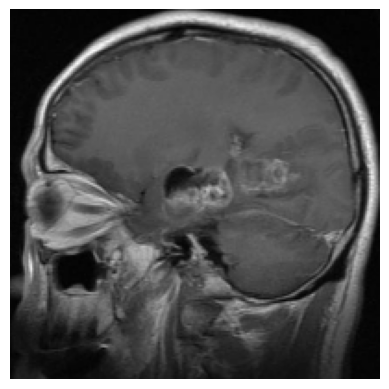

In [3]:
def crop_img(img):
	"""
	Finds the extreme points on the image and crops the rectangular out of them
	"""
	gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
	gray = cv2.GaussianBlur(gray, (3, 3), 0)

	# threshold the image, then perform a series of erosions +
	# dilations to remove any small regions of noise
	thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
	thresh = cv2.erode(thresh, None, iterations=2)
	thresh = cv2.dilate(thresh, None, iterations=2)

	# find contours in thresholded image, then grab the largest one
	cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
	cnts = imutils.grab_contours(cnts)
	c = max(cnts, key=cv2.contourArea)

	# find the extreme points
	extLeft = tuple(c[c[:, :, 0].argmin()][0])
	extRight = tuple(c[c[:, :, 0].argmax()][0])
	extTop = tuple(c[c[:, :, 1].argmin()][0])
	extBot = tuple(c[c[:, :, 1].argmax()][0])
	ADD_PIXELS = 0
	new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
	
	return new_img

image_path = "/Users/sarthakkale/Documents/TDA/Code/MRI/Training/glioma/Tr-gl_0050.jpg"

# Load and preprocess the image
IMG_SIZE = 200
image = cv2.imread(image_path)

cropped = crop_img(image)
resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB) #This step is necessary for displaying the image correctly in matplotlib (We will remove it when training for the whole folder)

# Show image in notebook
plt.imshow(resized_rgb)
plt.axis("off")
plt.show()

## Preprocessing Pt.1
- All the 4 folders will be preprocessed wrt to the crop function and resized.
- Results will be saved in a new preprocessed folder.

In [30]:
input_dir = "MRI/Training/glioma"
output_dir = "MRI/Training/glioma_preprocessed"
os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = 256
for filename in os.listdir(input_dir):
    if filename.lower().endswith(".jpg"):
        image_path = os.path.join(input_dir, filename)
        image = cv2.imread(image_path)
        cropped = crop_img(image)
        resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, resized)

In [31]:
input_dir = "MRI/Training/meningioma"
output_dir = "MRI/Training/meningioma_preprocessed"
os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = 256
for filename in os.listdir(input_dir):
    if filename.lower().endswith(".jpg"):
        image_path = os.path.join(input_dir, filename)
        image = cv2.imread(image_path)
        cropped = crop_img(image)
        resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, resized)

In [32]:
input_dir = "MRI/Training/notumor"
output_dir = "MRI/Training/notumor_preprocessed"
os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = 256
for filename in os.listdir(input_dir):
    if filename.lower().endswith(".jpg"):
        image_path = os.path.join(input_dir, filename)
        image = cv2.imread(image_path)
        cropped = crop_img(image)
        resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, resized)

In [33]:
input_dir = "MRI/Training/pituitary"
output_dir = "MRI/Training/pituitary_preprocessed"
os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = 256
for filename in os.listdir(input_dir):
    if filename.lower().endswith(".jpg"):
        image_path = os.path.join(input_dir, filename)
        image = cv2.imread(image_path)
        cropped = crop_img(image)
        resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, resized)

## Preprocessing Pt.2
- We will take first 40 images from the preprocessed folders.
- Pass the images to the NIVE.

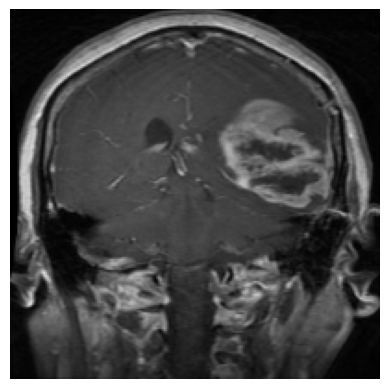

In [30]:
# Initialize a list to contain the first 44 images.
filenames = []

# Initialize a string containing the file path.
file_path = "MRI/Training/glioma_preprocessed/"

# Iterate through the folder and add the first 44 files to the list.
for i in range(10, 55):
  filenames.append(file_path + "Tr-gl_00" + str(i) + ".jpg")
  
#image_path = random.choice(filenames)
image_path = "MRI/Training/glioma_preprocessed/Tr-gl_0020.jpg"
image = cv2.imread(image_path)

resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB) #This step is necessary for displaying the image correctly in matplotlib (We will remove it when training for the whole folder)

# Show image in notebook
plt.imshow(resized_rgb)
plt.axis("off")
plt.show()


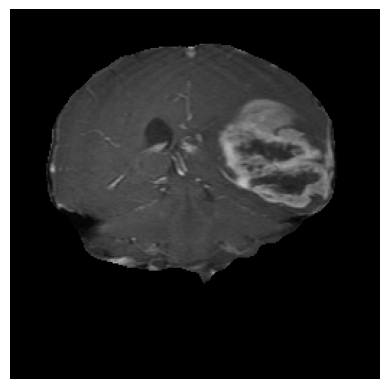

In [31]:
# Use current directory where notebook and .m/.mat files are located
eng.cd(os.getcwd(), nargout=0)
model_path = os.path.abspath("NIVE.mat")

# Run the MATLAB function
result = eng.nive_extract_brain(image_path, model_path)

# Convert MATLAB array to NumPy
# result is a 3D array in column-major (Fortran-style)
shape = tuple(result.size)  # (height, width, channels)
skull_np_array = np.array(result._data, dtype=np.uint8).reshape(shape, order='F')

# Display using matplotlib
plt.imshow(skull_np_array)
plt.axis('off')
plt.show()


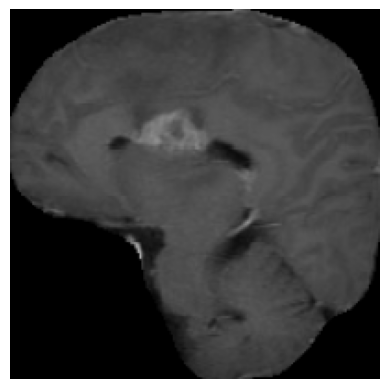

In [29]:
cropped_skull = crop_img(skull_np_array)
resized_skull = cv2.resize(cropped_skull, (200, 200), interpolation=cv2.INTER_AREA)
# Display the cropped and resized skull image
plt.imshow(resized_skull)
plt.axis('off')
plt.show()

## Performing TDA
- We will obtain the cubical persistence diagram for the skull-stripped images.
- We will obtain the persistence landscape for the skull-stripped images.

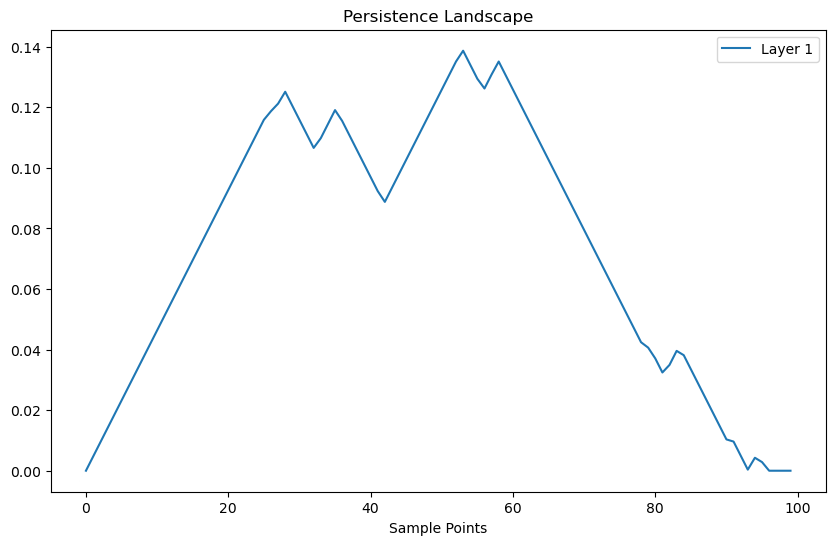

In [ ]:
# Convert to grayscale for TDA
gray = cv2.cvtColor(resized_skull, cv2.COLOR_RGB2GRAY)  # MATLAB gives RGB by default
gray_normalized = gray / 255.0  # Normalize to [0,1]

# Replace black background with mid-gray instead of NaN
gray_normalized[gray_normalized == 0] = 0.5

# Reshape for giotto-tda
X = gray_normalized[np.newaxis, :, :]

# Compute cubical persistence
cp = CubicalPersistence(homology_dimensions=(0, 1))
cp.fit(X)
diagrams = cp.fit_transform(X)

# Plot the persistence diagram
fig = cp.plot(diagrams, sample=0)
fig.update_layout(title="Persistence Diagram (Skull-Stripped Image)")
fig.show()

# Compute persistence landscape
pl = PersistenceLandscape(n_layers=5) 
landscapes = pl.fit_transform(diagrams)

# Plot the persistence landscape
plt.figure(figsize=(10, 6))
#for i in range(min(5, landscapes.shape[1])): 
plt.plot(landscapes[0, 1], label=f'Layer {1}')
plt.xlabel("Sample Points")
plt.title("Persistence Landscape")
plt.legend()
plt.show()

## Perform CLAHE + TDA
- We will perform CLAHE on the skull-stripped images.
- We will obtain the cubical persistence diagram for the CLAHE images.
- We will obtain the persistence landscape for the CLAHE images.

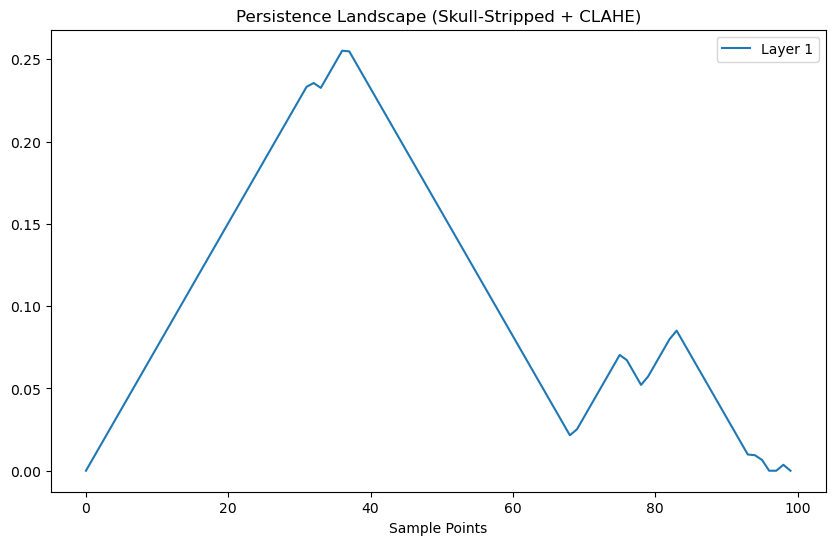

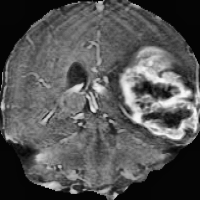

In [21]:
# Convert RGB to Grayscale
gray_skull_stripped = cv2.cvtColor(resized_skull, cv2.COLOR_RGB2GRAY)

# Apply CLAHE
clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
clahe_skull = clahe.apply(gray_skull_stripped)

# Normalize to [0, 1] for GTDA
normalized_clahe_skull = clahe_skull / 255.0
normalized_clahe_skull[normalized_clahe_skull < 0.02] = 0.5

# Reshape for giotto-tda
X_clahe_skull = normalized_clahe_skull[np.newaxis, :, :]  # Shape: (1, H, W)

# Compute Cubical Persistence
cp_skull = CubicalPersistence(homology_dimensions=(0, 1))
cp_skull.fit(X_clahe_skull)
diagrams_skull = cp_skull.fit_transform(X_clahe_skull)

# Plot Persistence Diagram
fig_skull = cp_skull.plot(diagrams_skull, sample=0)
fig_skull.update_layout(title="Persistence Diagram (Skull-Stripped + CLAHE)")
fig_skull.show()

# Compute persistence landscape
pl = PersistenceLandscape(n_layers=5) 
landscapes = pl.fit_transform(diagrams_skull)

# Plot the persistence landscape
plt.figure(figsize=(10, 6))
#for i in range(min(5, landscapes.shape[1])): 
plt.plot(landscapes[0, 1], label=f'Layer {1}')
plt.xlabel("Sample Points")
plt.title("Persistence Landscape (Skull-Stripped + CLAHE)")
plt.legend()
plt.show()

# Convert clahe_img to a PIL image
clahe_img = Image.fromarray(clahe_skull)

# Display the CLAHE image
clahe_img

In [20]:
print("Min pixel value after CLAHE:", normalized_clahe_skull.min())
print("Unique pixel values (sample):", np.unique(normalized_clahe_skull)[:10])
#Think about OTSU thresholding

Min pixel value after CLAHE: 0.011764705882352941
Unique pixel values (sample): [0.01176471 0.01568627 0.01960784 0.02352941 0.02745098 0.03137255
 0.03529412 0.03921569 0.04313725 0.04705882]
